# Step 1: Data Cleaning & Exploration
## Comparative Lassa-Ebola Mutation Study

This notebook:
1. Loads FASTA files from GitHub
2. Cleans and validates protein sequences
3. Explores sequence characteristics
4. Saves cleaned data for next steps

### Setup: Install Dependencies & Connect to GitHub

In [1]:
# Install required packages
!pip install biopython pandas numpy matplotlib seaborn -q

import pandas as pd
import numpy as np
from Bio import SeqIO
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("✅ All packages imported successfully")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 15.7 MB/s eta 0:00:00
✅ All packages imported successfully


### Step 1a: Download Data from GitHub

**What we're doing:**
- Downloading your FASTA files from your GitHub repo
- No need for authentication if repo is public
- Raw URL format: https://raw.githubusercontent.com/username/repo/branch/filename

In [2]:
import urllib.request

# GitHub raw content URLs for your files
repo_owner = "Damilola-max"
repo_name = "Comparative_Lassa_Ebola-Model"
branch = "main"

# File URLs
s_protein_url = f"https://raw.githubusercontent.com/{repo_owner}/{repo_name}/{branch}/S_protein.fas"
ebola_url = f"https://raw.githubusercontent.com/{repo_owner}/{repo_name}/{branch}/Ebola_Protein_Sequence.fas"

# Download files to Colab
print("Downloading S protein sequences...")
urllib.request.urlretrieve(s_protein_url, "S_protein.fas")
print("✅ S protein downloaded")

print("\nDownloading Ebola sequences...")
urllib.request.urlretrieve(ebola_url, "Ebola_Protein_Sequence.fas")
print("✅ Ebola sequences downloaded")

# Verify files
print("\n📁 Files in current directory:")
for f in os.listdir('.'):
    if f.endswith('.fas'):
        size = os.path.getsize(f) / 1024  # KB
        print(f"  - {f}: {size:.1f} KB")

✅ S protein downloaded

✅ Ebola sequences downloaded

📁 Files in current directory:
  - S_protein.fas: 869.8 KB
  - Ebola_Protein_Sequence.fas: 10030.2 KB


### Step 1b: Parse & Validate Sequences

**What we're doing:**
- Reading FASTA files using BioPython
- Checking for valid amino acids (A-Z standard codes)
- Removing sequences that are too short (<50 amino acids)
- Removing sequences with too many gaps/unknown residues
- Calculating basic statistics

In [3]:
def parse_fasta(fasta_file, virus_name):
    """
    Parse FASTA file and validate sequences.

    Parameters:
    -----------
    fasta_file : str
        Path to FASTA file
    virus_name : str
        Name of virus (for labeling)

    Returns:
    --------
    list of dict : Each dict contains sequence info
    """
    sequences = []
    invalid_seqs = []

    # Valid amino acid codes
    valid_aa = set('ACDEFGHIKLMNPQRSTVWYXU')  # Including X (unknown) and U (selenocysteine)

    for i, record in enumerate(SeqIO.parse(fasta_file, "fasta")):
        seq = str(record.seq).upper()
        seq_id = record.id

        # Check 1: Minimum length
        if len(seq) < 50:
            invalid_seqs.append({
                'id': seq_id,
                'reason': f'Too short ({len(seq)} aa)'
            })
            continue

        # Check 2: Invalid characters
        invalid_chars = set(seq) - valid_aa
        if invalid_chars:
            print(f"⚠️  {seq_id}: Contains invalid characters {invalid_chars}")

        # Check 3: Too many unknowns
        unknown_ratio = seq.count('X') / len(seq)
        if unknown_ratio > 0.1:  # More than 10% unknown
            invalid_seqs.append({
                'id': seq_id,
                'reason': f'Too many unknown residues ({unknown_ratio*100:.1f}%)'
            })
            continue

        # This sequence is valid
        sequences.append({
            'id': seq_id,
            'sequence': seq,
            'length': len(seq),
            'n_unknown': seq.count('X'),
            'virus': virus_name
        })

    return sequences, invalid_seqs

# Parse both files
print("Parsing S protein sequences...")
s_seqs, s_invalid = parse_fasta("S_protein.fas", "Lassa")
print(f"✅ Loaded {len(s_seqs)} valid Lassa S sequences")
print(f"⚠️  Skipped {len(s_invalid)} invalid sequences")

print("\nParsing Ebola sequences...")
e_seqs, e_invalid = parse_fasta("Ebola_Protein_Sequence.fas", "Ebola")
print(f"✅ Loaded {len(e_seqs)} valid Ebola sequences")
print(f"⚠️  Skipped {len(e_invalid)} invalid sequences")

# Combine
all_seqs = s_seqs + e_seqs
print(f"\n📊 TOTAL: {len(all_seqs)} valid sequences")

# Show invalid sequences
if s_invalid or e_invalid:
    print("\nInvalid sequences details:")
    for inv in s_invalid[:5]:  # Show first 5
        print(f"  - {inv['id']}: {inv['reason']}")

Parsing S protein sequences...
⚠️  X52400|s|LIII|3417: Contains invalid characters {'*'}
⚠️  OL774861|s|LIII|3371: Contains invalid characters {'*'}
⚠️  MK107965|s|LIII|3407: Contains invalid characters {'*'}
⚠️  OM140831|s|LIII|3420: Contains invalid characters {'*'}
⚠️  MH053478|s|LIII|3335: Contains invalid characters {'*'}
⚠️  MG812635|s|LIII|3410: Contains invalid characters {'*'}
⚠️  AY628206|s|LIII|3420: Contains invalid characters {'*'}
⚠️  MK107929|s|LIII|3383: Contains invalid characters {'*'}
⚠️  MH053476|s|LIII|3383: Contains invalid characters {'*'}
⚠️  GU481070|s|LIII|3382: Contains invalid characters {'?', '*'}
⚠️  GU481072|s|LIII|3383: Contains invalid characters {'*'}
⚠️  MZ169799|s|LIII|3368: Contains invalid characters {'*'}
⚠️  OM140829|s|LIII|3421: Contains invalid characters {'?', '*'}
⚠️  MK107941|s|LIII|3445: Contains invalid characters {'*'}
⚠️  MK117971|s|LIII|3368: Contains invalid characters {'?', '*'}
⚠️  MH887809|s|LIII|3243: Contains invalid characters {'

### Step 1c: Data Exploration & Statistics

**What we're learning:**
- Sequence length distribution
- Differences between Lassa and Ebola
- Data quality

In [4]:
# Create DataFrame
df = pd.DataFrame(all_seqs)

print("="*60)
print("SEQUENCE STATISTICS")
print("="*60)

# Overall stats
print(f"\n📊 Total Sequences: {len(df)}")
print(f"  - Lassa (S protein): {len(df[df['virus']=='Lassa'])}")
print(f"  - Ebola: {len(df[df['virus']=='Ebola'])}")

# Length statistics
print(f"\n📏 Sequence Length Statistics:")
for virus in ['Lassa', 'Ebola']:
    virus_df = df[df['virus']==virus]
    print(f"\n  {virus}:")
    print(f"    - Min length: {virus_df['length'].min()} aa")
    print(f"    - Max length: {virus_df['length'].max()} aa")
    print(f"    - Mean length: {virus_df['length'].mean():.0f} aa")
    print(f"    - Std Dev: {virus_df['length'].std():.0f} aa")

# Unknown residues
print(f"\n❓ Unknown Residues (X):")
print(f"  - Max X in any sequence: {df['n_unknown'].max()}")
print(f"  - Mean X per sequence: {df['n_unknown'].mean():.1f}")

# Show sample sequences
print(f"\n🔬 Sample Sequences (first 3):")
for idx, row in df.head(3).iterrows():
    print(f"\n  [{idx+1}] {row['id']} ({row['virus']})")
    print(f"       Length: {row['length']} aa")
    print(f"       First 50 aa: {row['sequence'][:50]}...")

SEQUENCE STATISTICS

📊 Total Sequences: 2390
  - Lassa (S protein): 780
  - Ebola: 1610

📏 Sequence Length Statistics:

  Lassa:
    - Min length: 796 aa
    - Max length: 1190 aa
    - Mean length: 1119 aa
    - Std Dev: 32 aa

  Ebola:
    - Min length: 6332 aa
    - Max length: 6332 aa
    - Mean length: 6332 aa
    - Std Dev: 0 aa

❓ Unknown Residues (X):
  - Max X in any sequence: 0
  - Mean X per sequence: 0.0

🔬 Sample Sequences (first 3):

  [1] X52400|s|LIII|3417 (Lassa)
       Length: 1139 aa
       First 50 aa: APGILGI*DCAF*NLLFGKCRNQDGTDCDILPRSSSCY*GSDEYCPYCTI...

  [2] OL774861|s|LIII|3371 (Lassa)
       Length: 1123 aa
       First 50 aa: AQWILGYWIALCTNQTFGVTTFKTH*GSDNHHDNECFQGSEVILVDSIPK...

  [3] MK107965|s|LIII|3407 (Lassa)
       Length: 1135 aa
       First 50 aa: IYISRRLRILEALFGDQTIRMGQIVTFFQEVPHVIEEVMNIVLIALTVLA...


### Step 1d: Create Data Visualization

/tmp/ipython-input-224/3497529434.py:53: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipython-input-224/3497529434.py:54: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  plt.savefig('01_data_exploration.png', dpi=300, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


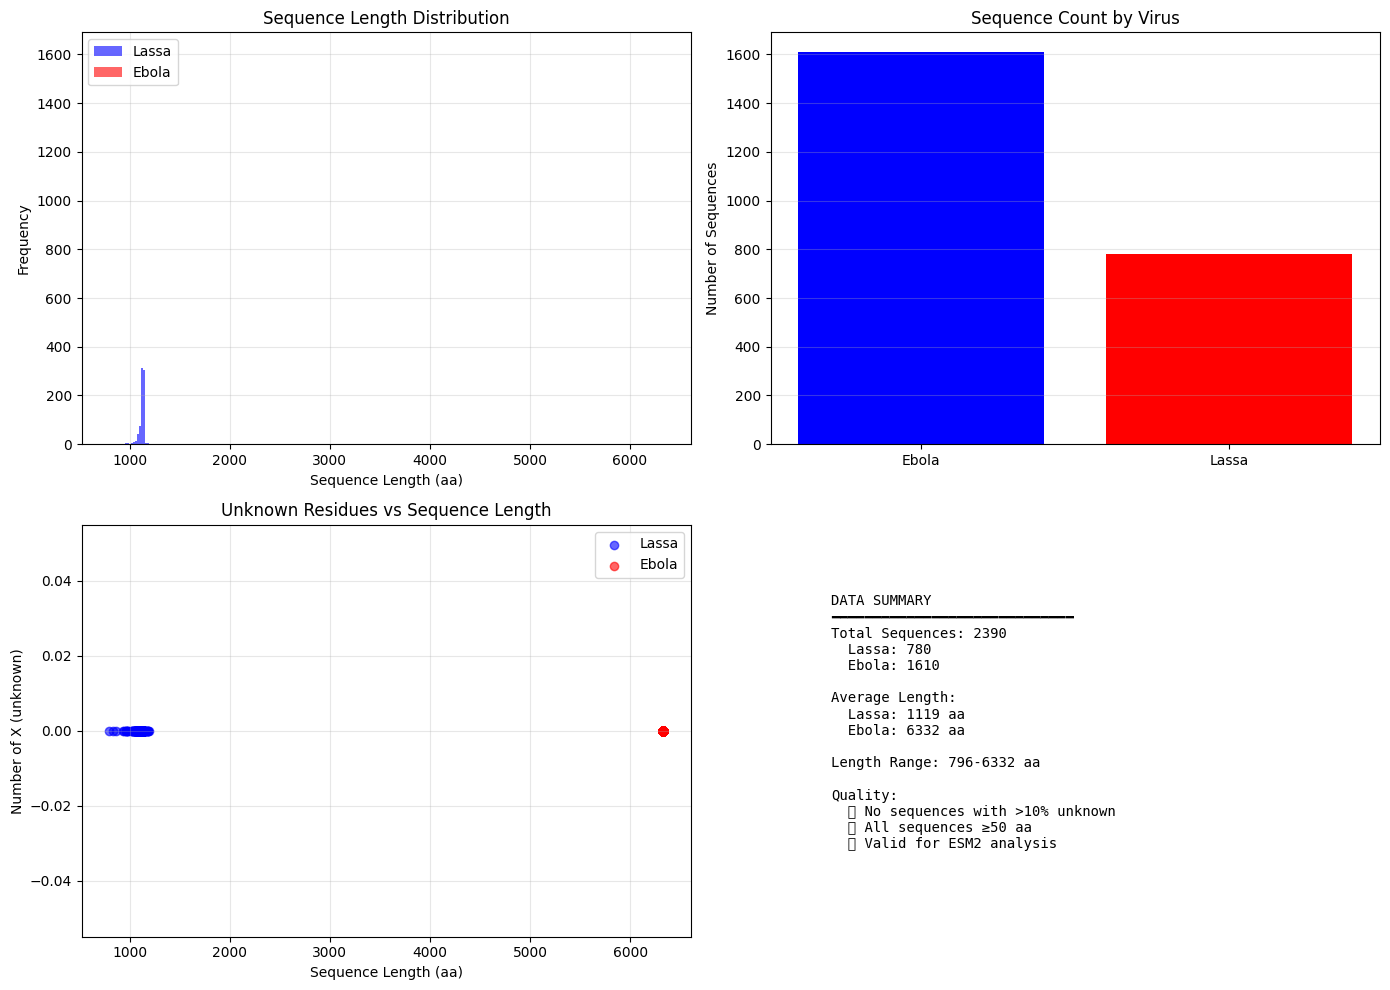


✅ Visualization saved as '01_data_exploration.png'


In [5]:
# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Length distribution
axes[0, 0].hist(df[df['virus']=='Lassa']['length'], bins=20, alpha=0.6, label='Lassa', color='blue')
axes[0, 0].hist(df[df['virus']=='Ebola']['length'], bins=20, alpha=0.6, label='Ebola', color='red')
axes[0, 0].set_xlabel('Sequence Length (aa)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Sequence Length Distribution')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Virus distribution
virus_counts = df['virus'].value_counts()
axes[0, 1].bar(virus_counts.index, virus_counts.values, color=['blue', 'red'])
axes[0, 1].set_ylabel('Number of Sequences')
axes[0, 1].set_title('Sequence Count by Virus')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# 3. Unknown residues
axes[1, 0].scatter(df[df['virus']=='Lassa']['length'], df[df['virus']=='Lassa']['n_unknown'],
                 alpha=0.6, label='Lassa', color='blue')
axes[1, 0].scatter(df[df['virus']=='Ebola']['length'], df[df['virus']=='Ebola']['n_unknown'],
                 alpha=0.6, label='Ebola', color='red')
axes[1, 0].set_xlabel('Sequence Length (aa)')
axes[1, 0].set_ylabel('Number of X (unknown)')
axes[1, 0].set_title('Unknown Residues vs Sequence Length')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Summary statistics table
axes[1, 1].axis('off')
summary_text = f"""DATA SUMMARY
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Total Sequences: {len(df)}
  Lassa: {len(df[df['virus']=='Lassa'])}
  Ebola: {len(df[df['virus']=='Ebola'])}

Average Length:
  Lassa: {df[df['virus']=='Lassa']['length'].mean():.0f} aa
  Ebola: {df[df['virus']=='Ebola']['length'].mean():.0f} aa

Length Range: {df['length'].min()}-{df['length'].max()} aa

Quality:
  ✅ No sequences with >10% unknown
  ✅ All sequences ≥50 aa
  ✅ Valid for ESM2 analysis
"""
axes[1, 1].text(0.1, 0.5, summary_text, fontfamily='monospace', fontsize=10,
              verticalalignment='center')

plt.tight_layout()
plt.savefig('01_data_exploration.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Visualization saved as '01_data_exploration.png'")

### Step 1e: Save Cleaned Data for Next Steps

In [6]:
# Save cleaned data as CSV
df.to_csv('cleaned_sequences.csv', index=False)
print(f"✅ Saved cleaned sequences to 'cleaned_sequences.csv'")
print(f"   Columns: {list(df.columns)}")
print(f"   Rows: {len(df)}")

# Save as FASTA (for next steps)
def save_cleaned_fasta(df, output_file):
    with open(output_file, 'w') as f:
        for idx, row in df.iterrows():
            header = f">{row['id']}|{row['virus']}|{row['length']}"
            f.write(header + "\n")
            f.write(row['sequence'] + "\n")
    print(f"✅ Saved cleaned sequences to '{output_file}'")

save_cleaned_fasta(df, 'cleaned_sequences.fasta')

# Summary stats
print(f"\n📋 Summary for next steps:")
print(f"  - Total sequences to analyze: {len(df)}")
print(f"  - All sequences are valid")
print(f"  - Ready for ESM2 embedding generation")

✅ Saved cleaned sequences to 'cleaned_sequences.csv'
   Columns: ['id', 'sequence', 'length', 'n_unknown', 'virus']
   Rows: 2390
✅ Saved cleaned sequences to 'cleaned_sequences.fasta'

📋 Summary for next steps:
  - Total sequences to analyze: 2390
  - All sequences are valid
  - Ready for ESM2 embedding generation


### Step 1f: Upload Results to GitHub

**Instructions:**
1. Download the generated files from Colab
2. Commit them to your GitHub repo with this structure:

```
Comparative_Lassa_Ebola-Model/
├── data/
│   ├── raw/
│   │   ├── S_protein.fas
│   │   └── Ebola_Protein_Sequence.fas
│   ├── cleaned/
│   │   ├── cleaned_sequences.csv
│   │   └── cleaned_sequences.fasta
│   └── results/
│       ├── 01_data_exploration.png
│       └── [future analysis results]
├── notebooks/
│   ├── 01_data_cleaning_exploration.ipynb
│   └── [future notebooks]
└── README.md
```